# causal-learn Tutorial 06: FCI For Latent Confounders

The PC algorithm is powerful, but it makes a strong assumption: all important common causes of the observed variables are themselves observed. That assumption is often too optimistic. If a hidden driver affects two measured variables, PC may explain the association by adding a directed edge between the measured variables, even when the real story is “there may be an unobserved common cause.”

This notebook introduces **FCI**, the Fast Causal Inference algorithm. FCI is a constraint-based causal discovery method like PC, but it is designed for settings where hidden confounders and selection effects may exist. Its output is not a DAG or a CPDAG. It is a **PAG**, or partial ancestral graph, where endpoint marks communicate what the data and assumptions can and cannot resolve.

The goal here is practical graph literacy:

- understand why PC can be overconfident when latent variables exist;
- run FCI on a synthetic dataset with one intentionally hidden common cause;
- read PAG endpoint marks such as tails, arrowheads, and circles;
- compare PC and FCI without pretending that FCI has identified every causal direction.

## Notebook Flow

We will work through the latent-confounding problem in a careful order:

1. Set up imports, output paths, and reusable graph helpers.
2. Load the hidden-confounder teaching data created earlier in the tutorial series.
3. Inspect the full data-generating graph, including the variable that will be hidden from the algorithms.
4. Run PC on the observed variables to show the overconfidence problem.
5. Run FCI on the same observed variables and inspect the PAG edge marks and edge properties.
6. Compare PC, FCI, and an oracle-style FCI run where the latent variable is included as observed.
7. Study alpha sensitivity because PAG endpoints can change when independence decisions change.
8. Save a compact reporting checklist for latent-confounder discovery workflows.

As before, every code cell is introduced with explanation and followed by a short discussion so the notebook reads like a tutorial rather than a pile of API calls.

## FCI Theory

FCI, or Fast Causal Inference, is a constraint-based discovery algorithm designed for settings where hidden confounders may exist. It extends the spirit of PC, but relaxes the causal sufficiency assumption.

Standard PC assumes that all common causes of measured variables are also measured. FCI does not. Instead of returning a DAG or CPDAG over the observed variables, FCI returns a PAG: a partial ancestral graph that represents a class of possible causal structures among observed variables when latent variables and selection effects may be present.

The price of this extra realism is caution. FCI often returns more endpoint uncertainty than PC, because it refuses to pretend that hidden variables are impossible.

## Why Latent Confounding Breaks Ordinary PC

Suppose an unobserved variable `U` causes both `X` and `Y`:

$$
X \leftarrow U \rightarrow Y
$$

If `U` is not in the dataset, `X` and `Y` may remain associated under many conditioning sets. Standard PC may represent that association with an ordinary edge between `X` and `Y`, even though neither variable directly causes the other.

This is the core motivation for FCI. The algorithm tries to distinguish ordinary directed causal relationships from relationships that may be explained by hidden common causes or selection structures.

## MAGs And PAGs In Plain Language

A MAG, or maximal ancestral graph, is a graph over observed variables that can represent the effects of latent confounders and selection bias without explicitly drawing the hidden variables. MAGs can contain directed edges and bidirected-style relationships.

A PAG represents a Markov equivalence class of MAGs. In other words, it summarizes what is and is not identifiable from the observed conditional independence pattern when hidden variables are allowed.

This is why FCI output contains endpoint marks rather than only arrows. The endpoint marks encode what the data and assumptions compel across the entire equivalence class.

## Endpoint Marks: Tail, Arrowhead, And Circle

FCI/PAG edges use endpoint marks to communicate uncertainty.

A **tail** at `X` on an edge between `X` and `Y` means the relationship is compatible with `X` being an ancestor of `Y` in the represented class.

An **arrowhead** at `Y` means `Y` is not an ancestor of `X` in the represented class.

A **circle** means the endpoint is unresolved. It is not a decorative mark; it is the algorithm saying that multiple causal explanations remain possible.

For example, `X o-> Y` is weaker than `X --> Y`. The arrowhead into `Y` is informative, but the circle at `X` says the other endpoint is not fully determined.

## FCI Search Logic

FCI begins similarly to PC: it uses conditional independence tests to remove edges and store separating sets. The difference is that FCI must consider that hidden variables can create dependencies that do not behave like ordinary observed-variable DAG paths.

After an initial skeleton phase, FCI expands the search using possible-D-SEP style sets. These sets allow the algorithm to test additional conditioning possibilities that PC would not consider under causal sufficiency.

FCI then applies orientation rules that are valid in the presence of latent confounding. These rules are more conservative than PC's DAG orientation rules because they must preserve uncertainty about hidden structures.

## Why FCI Is More Cautious Than PC

When FCI returns a circle endpoint, it is not failing to be useful. It is preserving uncertainty that would be unsafe to erase.

PC might orient an edge because it assumes no hidden common cause exists. FCI may leave the same endpoint unresolved because a latent-variable explanation is also compatible with the observed independencies.

This makes FCI especially useful for observational business, social, medical, and recommender-system data, where unmeasured user intent, demand, quality, or exposure processes are often plausible.

## What FCI Can And Cannot Claim

FCI can reveal where the observed data support adjacency, non-adjacency, ancestral constraints, and possible latent-confounding patterns. It is often more honest than PC when hidden confounding is plausible.

FCI cannot identify every hidden variable or fully reconstruct the underlying causal DAG. It also depends on the quality of conditional independence tests, faithfulness-style assumptions, and sufficient sample size.

A good FCI report explains endpoint marks carefully. The output should not be simplified into a fully directed DAG unless additional assumptions or background knowledge justify that simplification.

## Setup

The setup cell imports the scientific stack, PC, FCI, and plotting utilities. FCI sometimes writes small orientation messages to standard output, so later helper functions capture those messages and store them in tables instead of letting them clutter the notebook.

In [1]:
from pathlib import Path
from importlib.metadata import PackageNotFoundError, version
import contextlib
import io
import os
import warnings

# Keep matplotlib cache writes inside the repository so execution works in restricted environments.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))
warnings.filterwarnings("ignore", message="IProgress not found.*")
warnings.filterwarnings("ignore", message=".*pkg_resources is deprecated.*")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

from causallearn.search.ConstraintBased.PC import pc
from causallearn.search.ConstraintBased.FCI import fci

# Resolve paths whether the notebook is run from the repository root or from this notebook folder.
CWD = Path.cwd()
if CWD.name == "causal_learn" and (CWD / "outputs").exists():
    NOTEBOOK_DIR = CWD
else:
    NOTEBOOK_DIR = (CWD / "notebooks" / "tutorials" / "causal_learn").resolve()

OUTPUT_DIR = NOTEBOOK_DIR / "outputs"
DATASET_DIR = OUTPUT_DIR / "datasets"
TABLE_DIR = OUTPUT_DIR / "tables"
FIGURE_DIR = OUTPUT_DIR / "figures"
for directory in [OUTPUT_DIR, DATASET_DIR, TABLE_DIR, FIGURE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

NOTEBOOK_PREFIX = "06"
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.facecolor"] = "white"

packages = ["causal-learn", "numpy", "pandas", "matplotlib", "seaborn"]
version_rows = []
for package in packages:
    try:
        package_version = version(package)
    except PackageNotFoundError:
        package_version = "not installed"
    version_rows.append({"package": package, "version": package_version})

package_versions = pd.DataFrame(version_rows)
package_versions.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_package_versions.csv", index=False)
display(package_versions)

,package,version
0,causal-learn,0.1.4.5
1,numpy,2.4.4
2,pandas,3.0.2
3,matplotlib,3.10.9
4,seaborn,0.13.2


The version table anchors the notebook to a concrete environment. This matters for FCI because small implementation or independence-test changes can alter endpoint marks in a PAG.

## Load The Hidden-Confounder Teaching Data

Notebook 02 created two related datasets:

- `02_hidden_confounder_full.csv` includes the latent driver `latent_demand`.
- `02_hidden_confounder_observed.csv` removes `latent_demand`, which is the dataset PC and FCI will usually see.

The full dataset exists only so this tutorial can explain the hidden structure. In an applied discovery problem, the hidden variable would not be available for inspection.

In [2]:
# Load observed data, full data, and the synthetic true edge tables.
observed_path = DATASET_DIR / "02_hidden_confounder_observed.csv"
full_path = DATASET_DIR / "02_hidden_confounder_full.csv"
observed_truth_path = TABLE_DIR / "02_hidden_confounder_observed_true_edges.csv"
full_truth_path = TABLE_DIR / "02_hidden_confounder_full_true_edges.csv"

required_paths = [observed_path, full_path, observed_truth_path, full_truth_path]
missing_paths = [str(path) for path in required_paths if not path.exists()]
if missing_paths:
    raise FileNotFoundError("Run tutorial notebook 02 first. Missing files: " + ", ".join(missing_paths))

observed_df = pd.read_csv(observed_path)
full_df = pd.read_csv(full_path)
observed_truth = pd.read_csv(observed_truth_path)
full_truth = pd.read_csv(full_truth_path)

OBSERVED_VARIABLES = list(observed_df.columns)
FULL_VARIABLES = list(full_df.columns)

loaded_summary = pd.DataFrame(
    [
        {
            "dataset": "hidden_confounder_observed",
            "rows": len(observed_df),
            "columns": observed_df.shape[1],
            "contains_latent_demand_column": "latent_demand" in observed_df.columns,
            "source_file": observed_path.name,
        },
        {
            "dataset": "hidden_confounder_full",
            "rows": len(full_df),
            "columns": full_df.shape[1],
            "contains_latent_demand_column": "latent_demand" in full_df.columns,
            "source_file": full_path.name,
        },
    ]
)
loaded_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_loaded_dataset_summary.csv", index=False)

display(loaded_summary)
display(observed_df.head())
display(full_df.head())

,dataset,rows,columns,contains_latent_demand_column,source_file
0,hidden_confounder_observed,2500,6,False,02_hidden_confounder_observed.csv
1,hidden_confounder_full,2500,7,True,02_hidden_confounder_full.csv


,need,intent,match,engagement,renewal,support
0,-0.670177,0.916751,-0.811025,-0.543636,-1.056283,-0.760347
1,0.099398,0.355660,0.738471,0.195636,1.231812,-0.037870
2,-1.912569,1.550731,0.853338,0.529918,0.922433,0.886718
3,-1.953293,-0.835806,-0.691733,-1.561579,-0.399516,-0.891322
4,-1.419799,1.690953,-0.839137,-0.319077,0.325408,-0.029369


,need,intent,latent_demand,match,engagement,renewal,support
0,-0.670177,0.916751,-1.978234,-0.811025,-0.543636,-1.056283,-0.760347
1,0.099398,0.355660,1.211701,0.738471,0.195636,1.231812,-0.037870
2,-1.912569,1.550731,1.095861,0.853338,0.529918,0.922433,0.886718
3,-1.953293,-0.835806,0.227012,-0.691733,-1.561579,-0.399516,-0.891322
4,-1.419799,1.690953,-1.899709,-0.839137,-0.319077,0.325408,-0.029369


The observed and full datasets have the same number of rows. The only difference is that the full dataset includes `latent_demand`, which will act as the hidden common cause in the main FCI demonstration.

## Field Guide For This Dataset

The next table documents the role of each variable. This is especially important in latent-variable notebooks because a reader needs to know which variable is intentionally hidden and which variables remain available to the discovery algorithms.

In [3]:
# Document observed variables and the intentionally hidden variable.
field_guide = pd.DataFrame(
    [
        {"variable": "need", "status": "observed", "role": "early context", "meaning": "baseline user need signal"},
        {"variable": "intent", "status": "observed", "role": "early context", "meaning": "current intent or short-term goal signal"},
        {"variable": "latent_demand", "status": "hidden in main analysis", "role": "unobserved common cause", "meaning": "unmeasured demand that affects match quality and renewal"},
        {"variable": "match", "status": "observed", "role": "intermediate", "meaning": "quality of the user-item match"},
        {"variable": "engagement", "status": "observed", "role": "intermediate", "meaning": "depth of short-term interaction"},
        {"variable": "renewal", "status": "observed", "role": "downstream outcome", "meaning": "future value or retention-like outcome"},
        {"variable": "support", "status": "observed", "role": "downstream outcome", "meaning": "future support or friction-like outcome"},
    ]
)
field_guide.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_field_guide.csv", index=False)

display(field_guide)
display(full_truth)

,variable,status,role,meaning
0,need,observed,early context,baseline user need signal
1,intent,observed,early context,current intent or short-term goal signal
2,latent_demand,hidden in main analysis,unobserved common cause,unmeasured demand that affects match quality a...
3,match,observed,intermediate,quality of the user-item match
4,engagement,observed,intermediate,depth of short-term interaction
5,renewal,observed,downstream outcome,future value or retention-like outcome
6,support,observed,downstream outcome,future support or friction-like outcome


,source,target,edge_type,mechanism
0,need,match,directed,Need changes what a good match means.
1,intent,match,directed,Current intent changes recommendation relevance.
2,match,engagement,directed,Better matching increases engagement depth.
3,intent,renewal,directed,Intent directly affects later value.
4,engagement,renewal,directed,Engagement contributes to renewal value.
5,engagement,support,directed,Engagement creates more chances for support co...
6,latent_demand,match,latent,Unobserved demand makes better matches more li...
7,latent_demand,renewal,latent,The same unobserved demand also affects renewal.


The key hidden structure is `latent_demand -> match` and `latent_demand -> renewal`. Once `latent_demand` is removed from the observed data, `match` and `renewal` can appear associated in a way that is not fully explained by a direct causal edge between them.

## Helper Functions For DAGs, PAGs, And Metrics

This helper cell does a lot of useful work for the rest of the notebook:

- converts PC and FCI graph objects into tidy edge tables;
- captures FCI orientation messages and edge properties;
- compares learned adjacencies with the observed synthetic truth;
- draws DAG and PAG edges with visible arrowheads and circle endpoints.

PAG drawing is more delicate than DAG drawing because endpoint marks carry meaning. The helper trims every edge to stop just outside the rounded boxes, then places arrowheads or circle marks at the trimmed endpoints.

In [4]:
def parse_causallearn_edge(edge):
    """Convert a causal-learn edge object into source, endpoint pattern, and target strings."""
    parts = str(edge).strip().split()
    if len(parts) != 3:
        return {"source": str(edge), "edge_type": "unknown", "target": "unknown"}
    return {"source": parts[0], "edge_type": parts[1], "target": parts[2]}


def graph_to_edge_table(graph, label, edge_properties=None):
    """Return a tidy edge table from a causal-learn Graph result."""
    rows = []
    property_lookup = {}
    if edge_properties is not None:
        for edge in edge_properties:
            parsed = parse_causallearn_edge(edge)
            key = (parsed["source"], parsed["edge_type"], parsed["target"])
            props = getattr(edge, "properties", [])
            property_lookup[key] = ",".join(getattr(prop, "name", str(prop)) for prop in props) or "none"

    for edge in graph.get_graph_edges():
        parsed = parse_causallearn_edge(edge)
        key = (parsed["source"], parsed["edge_type"], parsed["target"])
        rows.append(
            {
                "run": label,
                "source": parsed["source"],
                "edge_type": parsed["edge_type"],
                "target": parsed["target"],
                "edge_properties": property_lookup.get(key, "not_returned" if edge_properties is None else "none"),
            }
        )
    return pd.DataFrame(rows, columns=["run", "source", "edge_type", "target", "edge_properties"])


def run_fci_quiet(data, label, node_names, alpha=0.05, depth=-1, max_path_length=-1):
    """Run FCI while capturing small orientation messages printed by the implementation."""
    buffer = io.StringIO()
    with contextlib.redirect_stdout(buffer):
        graph, edges = fci(
            data,
            independence_test_method="fisherz",
            alpha=alpha,
            depth=depth,
            max_path_length=max_path_length,
            verbose=False,
            show_progress=False,
            node_names=node_names,
        )
    messages = [line for line in buffer.getvalue().splitlines() if line.strip()]
    return graph, edges, pd.DataFrame({"run": label, "message": messages})


def endpoint_category(edge_type):
    """Map causal-learn edge strings to a plain-language PAG category."""
    if edge_type in {"-->", "<--"}:
        return "definite directed edge"
    if edge_type in {"o->", "<-o"}:
        return "partially oriented edge"
    if edge_type == "<->":
        return "possible latent-confounding edge"
    if edge_type in {"o-o", "---"}:
        return "unresolved adjacency"
    return "other endpoint pattern"


def directed_pairs(edge_df):
    """Extract only definite directed pairs from an edge table."""
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.edge_type == "-->":
            pairs.add((row.source, row.target))
        elif row.edge_type == "<--":
            pairs.add((row.target, row.source))
    return pairs


def skeleton_pairs(edge_df):
    """Extract adjacencies while ignoring endpoint marks."""
    pairs = set()
    for row in edge_df.itertuples(index=False):
        if row.target != "unknown":
            pairs.add(frozenset([row.source, row.target]))
    return pairs


def summarize_against_observed_truth(edge_df, truth_df, label):
    """Compute compact recovery metrics against the observed-variable truth table."""
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    learned_directed = directed_pairs(edge_df)
    learned_skeleton = skeleton_pairs(edge_df)

    correct_directed = learned_directed & true_directed
    reversed_true = {(src, dst) for src, dst in true_directed if (dst, src) in learned_directed}
    missing_skeleton = true_skeleton - learned_skeleton
    extra_skeleton = learned_skeleton - true_skeleton

    partially_oriented = int(edge_df["edge_type"].isin(["o->", "<-o"]).sum())
    bidirected_like = int((edge_df["edge_type"] == "<->").sum())
    unresolved = int(edge_df["edge_type"].isin(["o-o", "---"]).sum())

    directed_count = len(learned_directed)
    return pd.DataFrame(
        [
            {
                "run": label,
                "learned_edges_total": len(edge_df),
                "definite_directed_edges": directed_count,
                "partially_oriented_edges": partially_oriented,
                "bidirected_like_edges": bidirected_like,
                "unresolved_adjacencies": unresolved,
                "correct_definite_directed_edges": len(correct_directed),
                "directed_precision": len(correct_directed) / directed_count if directed_count else np.nan,
                "directed_recall": len(correct_directed) / len(true_directed) if true_directed else np.nan,
                "reversed_true_edges": len(reversed_true),
                "missing_true_adjacencies": len(missing_skeleton),
                "extra_adjacencies": len(extra_skeleton),
            }
        ]
    )


def classify_edges(edge_df, truth_df):
    """Label learned edges relative to the observed synthetic truth table."""
    true_directed = set(zip(truth_df["source"], truth_df["target"]))
    true_skeleton = {frozenset(edge) for edge in true_directed}
    rows = []
    for row in edge_df.itertuples(index=False):
        pair = frozenset([row.source, row.target])
        learned_direction = None
        if row.edge_type == "-->":
            learned_direction = (row.source, row.target)
        elif row.edge_type == "<--":
            learned_direction = (row.target, row.source)

        if learned_direction in true_directed:
            status = "correct definite direction"
        elif learned_direction and (learned_direction[1], learned_direction[0]) in true_directed:
            status = "reversed definite direction"
        elif pair in true_skeleton:
            status = "true adjacency with non-definite endpoint"
        else:
            status = "extra observed adjacency"
        rows.append(
            {
                "source": row.source,
                "edge_type": row.edge_type,
                "target": row.target,
                "endpoint_category": endpoint_category(row.edge_type),
                "edge_properties": row.edge_properties,
                "status_vs_observed_truth": status,
            }
        )
    return pd.DataFrame(rows)


def hidden_common_cause_pairs(full_truth_df):
    """Find observed variable pairs that share a latent parent in the synthetic full truth table."""
    latent_edges = full_truth_df[full_truth_df["source"].str.startswith("latent")]
    rows = []
    for latent, group in latent_edges.groupby("source"):
        children = sorted(group["target"].tolist())
        for i, left in enumerate(children):
            for right in children[i + 1 :]:
                rows.append({"latent_variable": latent, "observed_child_a": left, "observed_child_b": right})
    return pd.DataFrame(rows)


OBS_POS = {
    "need": (0.10, 0.72),
    "intent": (0.10, 0.28),
    "match": (0.38, 0.50),
    "engagement": (0.62, 0.50),
    "renewal": (0.90, 0.72),
    "support": (0.90, 0.28),
}
FULL_POS = {
    "need": (0.08, 0.74),
    "intent": (0.08, 0.26),
    "latent_demand": (0.36, 0.82),
    "match": (0.36, 0.46),
    "engagement": (0.62, 0.46),
    "renewal": (0.90, 0.74),
    "support": (0.90, 0.26),
}
NODE_COLORS = {
    "need": "#e0f2fe",
    "intent": "#dbeafe",
    "latent_demand": "#f3f4f6",
    "match": "#ecfccb",
    "engagement": "#fef3c7",
    "renewal": "#fee2e2",
    "support": "#f3e8ff",
}
NODE_LABELS = {
    "need": "Need",
    "intent": "Intent",
    "latent_demand": "Latent\nDemand",
    "match": "Match",
    "engagement": "Engagement",
    "renewal": "Renewal",
    "support": "Support",
}


def trim_edge_to_box(start, end, box_w=0.145, box_h=0.105, gap=0.018):
    """Return edge endpoints that stop just outside source and target boxes."""
    x0, y0 = start
    x1, y1 = end
    dx = x1 - x0
    dy = y1 - y0
    length = float(np.hypot(dx, dy))
    if length == 0:
        return start, end
    x_limit = (box_w / 2) / abs(dx) if dx else np.inf
    y_limit = (box_h / 2) / abs(dy) if dy else np.inf
    t = min(x_limit, y_limit) + gap / length
    return (x0 + dx * t, y0 + dy * t), (x1 - dx * t, y1 - dy * t)


def add_endpoint_mark(ax, point, other, mark, color="#334155"):
    """Draw a PAG endpoint mark at a trimmed edge endpoint."""
    if mark == "arrow":
        return
    if mark == "circle":
        ax.scatter(
            [point[0]],
            [point[1]],
            s=80,
            facecolor="white",
            edgecolor=color,
            linewidth=1.7,
            zorder=4,
        )
    elif mark == "tail":
        x, y = point
        ox, oy = other
        dx, dy = x - ox, y - oy
        length = float(np.hypot(dx, dy))
        if length == 0:
            return
        nx_, ny_ = -dy / length, dx / length
        half = 0.014
        ax.plot([x - nx_ * half, x + nx_ * half], [y - ny_ * half, y + ny_ * half], color=color, linewidth=1.8, zorder=4)


def endpoint_marks(edge_type):
    """Return source and target endpoint marks for a causal-learn edge string."""
    if edge_type == "-->":
        return "tail", "arrow"
    if edge_type == "<--":
        return "arrow", "tail"
    if edge_type == "o->":
        return "circle", "arrow"
    if edge_type == "<-o":
        return "arrow", "circle"
    if edge_type == "<->":
        return "arrow", "arrow"
    if edge_type == "o-o":
        return "circle", "circle"
    return "tail", "tail"


def draw_pag_or_dag(edge_df, title, path, positions, note=None, show_endpoint_labels=False):
    """Draw a DAG/PAG-style graph with rounded nodes and visible endpoint marks."""
    fig, ax = plt.subplots(figsize=(12, 6.3))
    ax.set_axis_off()
    box_w, box_h = 0.145, 0.105

    for row in edge_df.itertuples(index=False):
        if row.source not in positions or row.target not in positions:
            continue
        raw_start = positions[row.source]
        raw_end = positions[row.target]
        start, end = trim_edge_to_box(raw_start, raw_end, box_w=box_w, box_h=box_h)
        source_mark, target_mark = endpoint_marks(row.edge_type)
        has_arrow = source_mark == "arrow" or target_mark == "arrow"

        if source_mark == "arrow" and target_mark == "arrow":
            arrowstyle = "<|-|>"
        elif target_mark == "arrow":
            arrowstyle = "-|>"
        elif source_mark == "arrow":
            arrowstyle = "<|-"
        else:
            arrowstyle = "-"

        color = "#334155" if row.edge_type != "<->" else "#7c2d12"
        arrow = FancyArrowPatch(
            start,
            end,
            arrowstyle=arrowstyle,
            mutation_scale=18 if has_arrow else 1,
            linewidth=1.8,
            color=color,
            connectionstyle="arc3,rad=0.035",
            zorder=2,
        )
        ax.add_patch(arrow)
        add_endpoint_mark(ax, start, end, source_mark, color=color)
        add_endpoint_mark(ax, end, start, target_mark, color=color)

        if show_endpoint_labels and row.edge_type not in {"-->", "<--"}:
            mid_x = (start[0] + end[0]) / 2
            mid_y = (start[1] + end[1]) / 2
            ax.text(mid_x, mid_y + 0.035, row.edge_type, ha="center", va="center", fontsize=9, color="#475569")

    for node, (x, y) in positions.items():
        rect = FancyBboxPatch(
            (x - box_w / 2, y - box_h / 2),
            box_w,
            box_h,
            boxstyle="round,pad=0.018",
            facecolor=NODE_COLORS.get(node, "#f8fafc"),
            edgecolor="#1f2937",
            linewidth=1.1,
            zorder=5,
        )
        ax.add_patch(rect)
        ax.text(x, y, NODE_LABELS.get(node, node), ha="center", va="center", fontsize=10.5, fontweight="bold", zorder=6)

    if note:
        ax.text(0.50, 0.08, note, ha="center", va="center", fontsize=10, color="#475569")
    ax.set_title(title, pad=18, fontsize=14, fontweight="bold")
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


def truth_as_edges(truth_df, label="truth"):
    """Convert a truth table with directed rows into the plotting schema."""
    return truth_df.assign(run=label, edge_type="-->", edge_properties="truth")[["run", "source", "edge_type", "target", "edge_properties"]]

The helper cell gives us a consistent grammar for the notebook. The most important piece is the endpoint-mark drawing: circles, tails, and arrowheads are drawn at trimmed edge endpoints so they remain visible and do not sit on top of the node labels.

## PAG Endpoint Vocabulary

FCI returns a PAG, so we need a small vocabulary before looking at results. A PAG edge does not always mean “this exact direct causal edge exists.” Its endpoint marks describe what can be concluded under the assumptions and the conditional independence evidence.

In [5]:
# Create a compact PAG endpoint guide for later reference.
pag_vocabulary = pd.DataFrame(
    [
        {"edge_pattern": "A --> B", "plain_language": "tail at A, arrowhead at B", "reading": "A is an ancestor-like candidate cause of B under the PAG semantics."},
        {"edge_pattern": "A o-> B", "plain_language": "circle at A, arrowhead at B", "reading": "The B endpoint is oriented, but the A endpoint is not resolved."},
        {"edge_pattern": "A <-> B", "plain_language": "arrowheads at both ends", "reading": "The pair may involve latent confounding or a non-directed ancestral relation."},
        {"edge_pattern": "A o-o B", "plain_language": "circles at both ends", "reading": "The adjacency is present, but neither endpoint is resolved."},
        {"edge_pattern": "edge property dd", "plain_language": "definitely direct", "reading": "FCI marks this edge as definitely direct in the returned edge properties."},
        {"edge_pattern": "edge property nl", "plain_language": "no latent", "reading": "FCI marks this edge as not involving a latent confounder in the returned edge properties."},
        {"edge_pattern": "edge property pd/pl", "plain_language": "possibly direct / possibly latent", "reading": "FCI is leaving a weaker, more cautious claim."},
    ]
)
pag_vocabulary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pag_endpoint_vocabulary.csv", index=False)
display(pag_vocabulary)

,edge_pattern,plain_language,reading
0,A --> B,"tail at A, arrowhead at B",A is an ancestor-like candidate cause of B und...
1,A o-> B,"circle at A, arrowhead at B","The B endpoint is oriented, but the A endpoint..."
2,A <-> B,arrowheads at both ends,The pair may involve latent confounding or a n...
3,A o-o B,circles at both ends,"The adjacency is present, but neither endpoint..."
4,edge property dd,definitely direct,FCI marks this edge as definitely direct in th...
5,edge property nl,no latent,FCI marks this edge as not involving a latent ...
6,edge property pd/pl,possibly direct / possibly latent,"FCI is leaving a weaker, more cautious claim."


This vocabulary is the guardrail for the rest of the notebook. A circle endpoint is not a decorative mark; it is FCI saying that the available evidence does not justify a fully definite endpoint there.

## Draw The Full Data-Generating Graph

The next figure includes `latent_demand`, even though the main algorithms will not observe it. This makes the hidden-confounder design explicit: a latent variable points to both `match` and `renewal`, creating a path that can make those observed variables look directly connected.

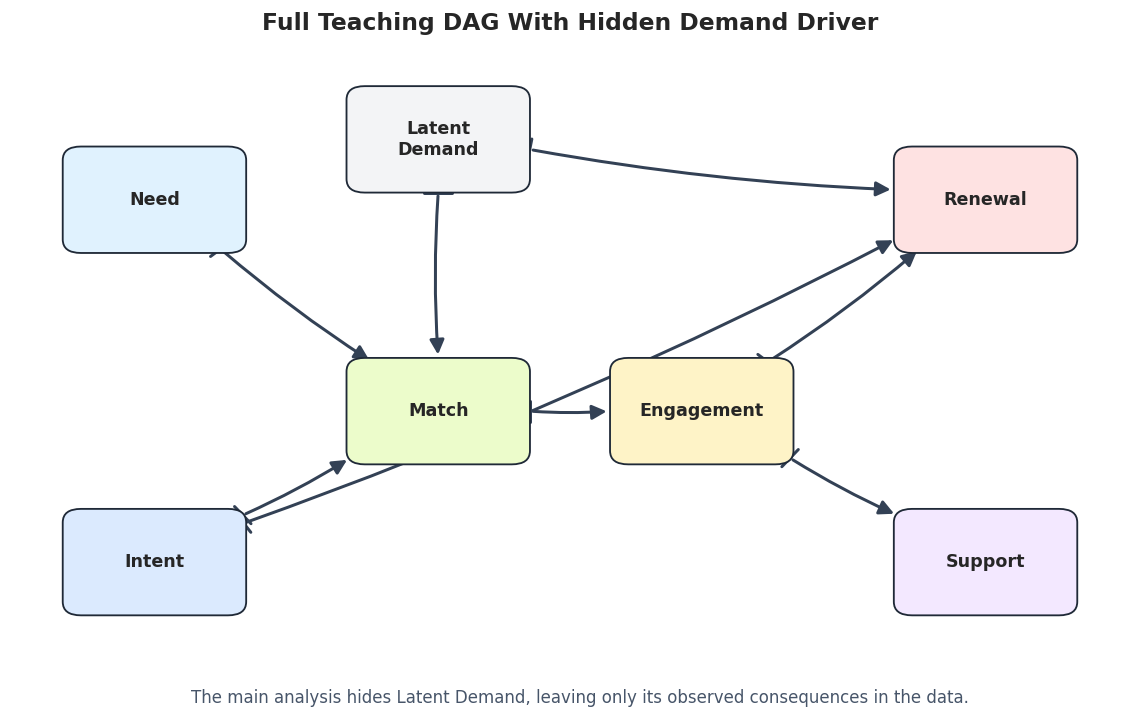

In [6]:
# Draw the full synthetic graph, including the variable that will be hidden from PC and FCI.
full_truth_edges = truth_as_edges(full_truth, label="full_truth")
full_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_full_truth_dag_with_latent.png"
draw_pag_or_dag(
    full_truth_edges,
    title="Full Teaching DAG With Hidden Demand Driver",
    path=full_graph_path,
    positions=FULL_POS,
    note="The main analysis hides Latent Demand, leaving only its observed consequences in the data.",
)

The full graph explains the central risk: if `latent_demand` is not measured, a discovery algorithm may represent its influence through extra observed edges. FCI is designed to be more cautious about exactly this problem.

## Identify The Hidden Common-Cause Pair

This cell converts the full truth table into a small audit table of observed variable pairs that share a latent parent. In this synthetic dataset, there is one such pair.

In [7]:
# Identify observed pairs that share the intentionally hidden parent.
latent_pair_table = hidden_common_cause_pairs(full_truth)
latent_pair_table.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_latent_common_cause_pairs.csv", index=False)
display(latent_pair_table)

,latent_variable,observed_child_a,observed_child_b
0,latent_demand,match,renewal


The table points us to the pair that deserves special attention: `match` and `renewal`. If PC returns a confident directed edge between them, that edge should be treated skeptically because we know the tutorial data contain a hidden common cause.

## Basic Observed-Data Audit

Before running discovery, we inspect the observed data matrix. FCI with Fisher-Z is still using conditional independence decisions based on continuous-variable partial correlations, so missingness, scale, and correlation structure are useful first checks.

In [8]:
# Summarize observed data quality and save a correlation matrix.
observed_audit = pd.DataFrame(
    {
        "variable": OBSERVED_VARIABLES,
        "missing_rate": observed_df.isna().mean().reindex(OBSERVED_VARIABLES).to_numpy(),
        "mean": observed_df.mean().reindex(OBSERVED_VARIABLES).to_numpy(),
        "std": observed_df.std().reindex(OBSERVED_VARIABLES).to_numpy(),
        "min": observed_df.min().reindex(OBSERVED_VARIABLES).to_numpy(),
        "max": observed_df.max().reindex(OBSERVED_VARIABLES).to_numpy(),
    }
)
observed_corr = observed_df[OBSERVED_VARIABLES].corr()

observed_audit.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_observed_data_audit.csv", index=False)
observed_corr.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_observed_correlation_matrix.csv")

display(observed_audit)
display(observed_corr.round(3))

,variable,missing_rate,mean,std,min,max
0,need,0.0,0.000000e+00,1.0002,-3.281714,3.642425
1,intent,0.0,3.126388e-17,1.0002,-3.534468,3.516284
2,match,0.0,1.705303e-17,1.0002,-3.271313,3.244364
3,engagement,0.0,1.207923e-17,1.0002,-3.431551,3.012661
4,renewal,0.0,1.136868e-17,1.0002,-3.603821,4.697521
5,support,0.0,1.278977e-17,1.0002,-3.798899,3.794992


,need,intent,match,engagement,renewal,support
need,1.000,0.001,0.496,0.405,0.140,0.234
intent,0.001,1.000,0.553,0.433,0.556,0.241
match,0.496,0.553,1.000,0.796,0.733,0.436
engagement,0.405,0.433,0.796,1.000,0.713,0.547
renewal,0.140,0.556,0.733,0.713,1.000,0.409
support,0.234,0.241,0.436,0.547,0.409,1.000


The observed variables are complete and standardized-like, so the main issue is not basic data quality. The correlation matrix hints at several associations, but it cannot by itself distinguish direct causation, mediated paths, and hidden common causes.

## Plot The Observed Correlation Matrix

A heatmap is a useful visual companion to the audit table. It gives a quick sense of which pairs are strongly related before any conditional independence search begins.

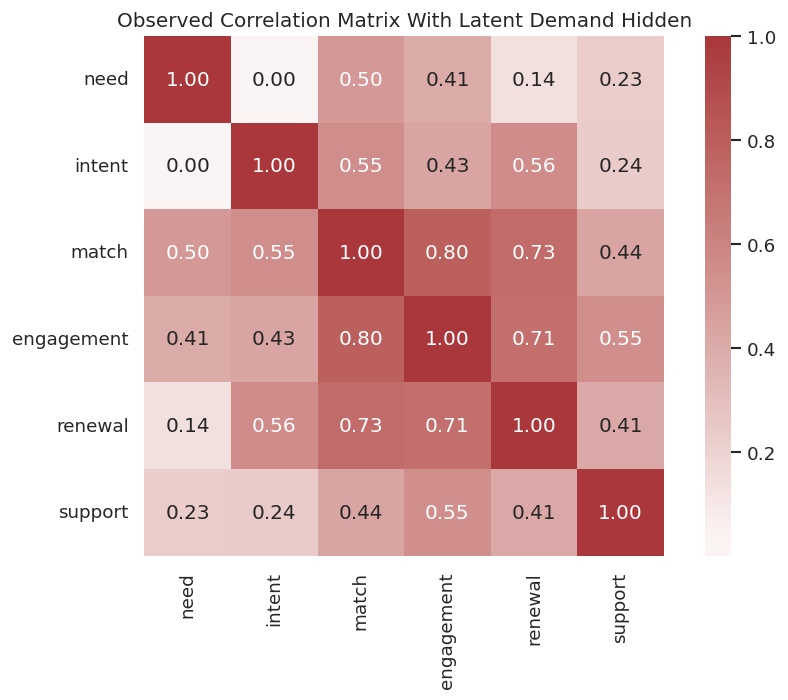

In [9]:
# Plot observed correlations as a first-pass dependence diagnostic.
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(observed_corr, annot=True, fmt=".2f", cmap="vlag", center=0, square=True, ax=ax)
ax.set_title("Observed Correlation Matrix With Latent Demand Hidden")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_observed_correlation_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

The heatmap shows why latent confounding is hard: associations are visible, but their causal explanation is ambiguous. PC and FCI now get the same observed matrix and must decide how much structure to assert.

## PC Baseline On The Observed Variables

We start with PC because it is the natural comparison point. PC assumes no hidden common causes among the observed variables. When that assumption is false, PC may still produce a crisp graph, but some crispness is artificial confidence.

In [10]:
# Run PC on the observed data, ignoring the hidden-confounder possibility.
pc_observed = pc(
    observed_df[OBSERVED_VARIABLES].to_numpy(),
    alpha=0.05,
    indep_test="fisherz",
    stable=True,
    show_progress=False,
    node_names=OBSERVED_VARIABLES,
)
pc_edges = graph_to_edge_table(pc_observed.G, label="pc_observed")
pc_metrics = summarize_against_observed_truth(pc_edges, observed_truth, "pc_observed")
pc_classified = classify_edges(pc_edges, observed_truth)

pc_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_observed_edges.csv", index=False)
pc_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_observed_metrics.csv", index=False)
pc_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_observed_edge_classification.csv", index=False)

display(pc_edges)
display(pc_metrics)
display(pc_classified)

,run,source,edge_type,target,edge_properties
0,pc_observed,need,-->,match,not_returned
1,pc_observed,need,-->,renewal,not_returned
2,pc_observed,intent,-->,match,not_returned
3,pc_observed,intent,-->,renewal,not_returned
4,pc_observed,match,-->,engagement,not_returned
5,pc_observed,match,-->,renewal,not_returned
6,pc_observed,engagement,-->,renewal,not_returned
7,pc_observed,engagement,-->,support,not_returned


,run,learned_edges_total,definite_directed_edges,partially_oriented_edges,bidirected_like_edges,unresolved_adjacencies,correct_definite_directed_edges,directed_precision,directed_recall,reversed_true_edges,missing_true_adjacencies,extra_adjacencies
0,pc_observed,8,8,0,0,0,6,0.75,1.0,0,0,2


,source,edge_type,target,endpoint_category,edge_properties,status_vs_observed_truth
0,need,-->,match,definite directed edge,not_returned,correct definite direction
1,need,-->,renewal,definite directed edge,not_returned,extra observed adjacency
2,intent,-->,match,definite directed edge,not_returned,correct definite direction
3,intent,-->,renewal,definite directed edge,not_returned,correct definite direction
4,match,-->,engagement,definite directed edge,not_returned,correct definite direction
5,match,-->,renewal,definite directed edge,not_returned,extra observed adjacency
6,engagement,-->,renewal,definite directed edge,not_returned,correct definite direction
7,engagement,-->,support,definite directed edge,not_returned,correct definite direction


PC returns a fully directed-looking candidate graph on the observed variables. The extra observed adjacencies are the warning sign: without a latent-variable representation, PC has to explain some hidden-common-cause signal using observed edges.

## Draw The PC Baseline Graph

The PC graph is useful precisely because it looks confident. Seeing the clean arrows makes the contrast with FCI's more cautious PAG easier to understand.

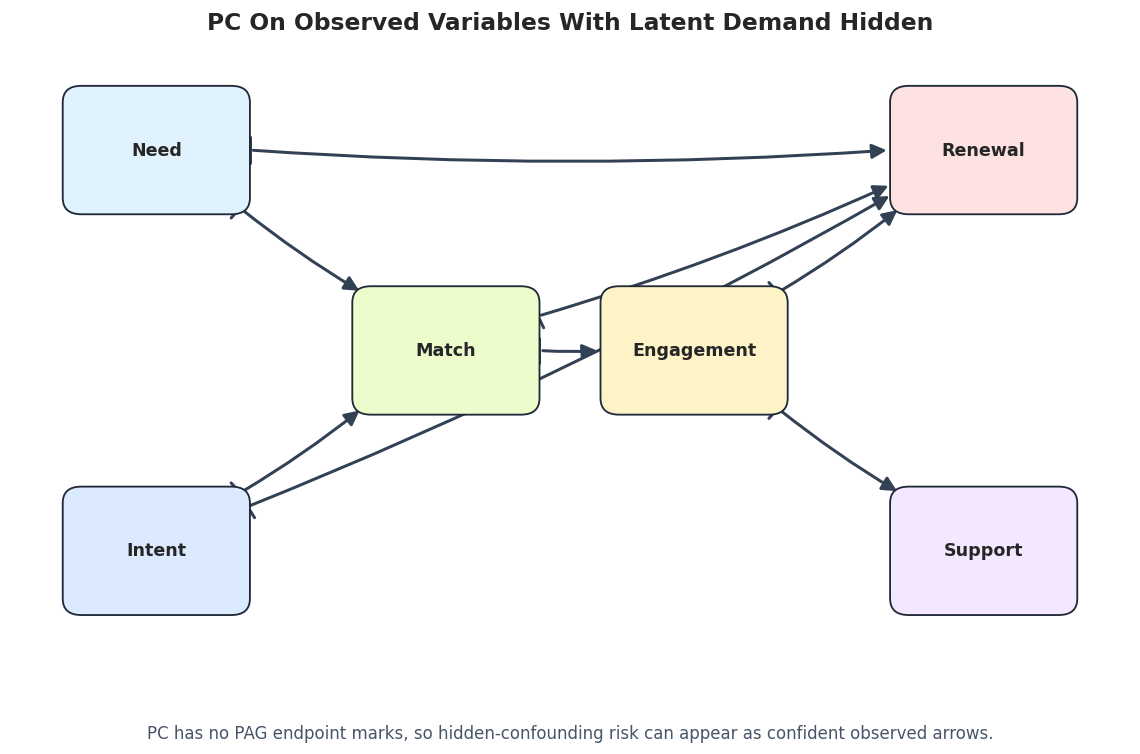

In [11]:
# Draw PC's observed-variable graph.
pc_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pc_observed_graph.png"
draw_pag_or_dag(
    pc_edges,
    title="PC On Observed Variables With Latent Demand Hidden",
    path=pc_graph_path,
    positions=OBS_POS,
    note="PC has no PAG endpoint marks, so hidden-confounding risk can appear as confident observed arrows.",
)

The PC graph has no way to say “this endpoint is uncertain because a hidden variable may exist.” FCI gives us that more cautious language, which is the next step.

## FCI On The Same Observed Variables

Now we run FCI using the same observed data and the same Fisher-Z test family. The key difference is the graph class: FCI returns a PAG whose endpoint marks allow latent-confounding and ancestral uncertainty to remain visible.

In [12]:
# Run FCI on the observed data while capturing implementation messages.
fci_graph, fci_properties, fci_messages = run_fci_quiet(
    observed_df[OBSERVED_VARIABLES].to_numpy(),
    label="fci_observed",
    node_names=OBSERVED_VARIABLES,
    alpha=0.05,
)

fci_edges = graph_to_edge_table(fci_graph, label="fci_observed", edge_properties=fci_properties)
fci_edges["endpoint_category"] = fci_edges["edge_type"].map(endpoint_category)
fci_metrics = summarize_against_observed_truth(fci_edges, observed_truth, "fci_observed")
fci_classified = classify_edges(fci_edges, observed_truth)

fci_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_observed_edges.csv", index=False)
fci_messages.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_observed_messages.csv", index=False)
fci_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_observed_metrics.csv", index=False)
fci_classified.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_observed_edge_classification.csv", index=False)

display(fci_edges)
display(fci_metrics)
display(fci_classified)

,run,source,edge_type,target,edge_properties,endpoint_category
0,fci_observed,need,o->,match,none,partially oriented edge
1,fci_observed,need,o->,renewal,none,partially oriented edge
2,fci_observed,intent,o->,match,none,partially oriented edge
3,fci_observed,intent,o->,renewal,none,partially oriented edge
4,fci_observed,match,-->,engagement,"dd,nl",definite directed edge
5,fci_observed,match,o->,renewal,none,partially oriented edge
6,fci_observed,engagement,o->,renewal,none,partially oriented edge
7,fci_observed,engagement,-->,support,"dd,nl",definite directed edge


,run,learned_edges_total,definite_directed_edges,partially_oriented_edges,bidirected_like_edges,unresolved_adjacencies,correct_definite_directed_edges,directed_precision,directed_recall,reversed_true_edges,missing_true_adjacencies,extra_adjacencies
0,fci_observed,8,2,6,0,0,2,1.0,0.333333,0,0,2


,source,edge_type,target,endpoint_category,edge_properties,status_vs_observed_truth
0,need,o->,match,partially oriented edge,none,true adjacency with non-definite endpoint
1,need,o->,renewal,partially oriented edge,none,extra observed adjacency
2,intent,o->,match,partially oriented edge,none,true adjacency with non-definite endpoint
3,intent,o->,renewal,partially oriented edge,none,true adjacency with non-definite endpoint
4,match,-->,engagement,definite directed edge,"dd,nl",correct definite direction
5,match,o->,renewal,partially oriented edge,none,extra observed adjacency
6,engagement,o->,renewal,partially oriented edge,none,true adjacency with non-definite endpoint
7,engagement,-->,support,definite directed edge,"dd,nl",correct definite direction


The FCI edge table is less forceful than the PC edge table. Several edges have circle endpoints or weaker properties, which means the algorithm is preserving uncertainty instead of converting every association into a definite directed edge.

## Draw The FCI PAG

This plot uses arrowheads, tails, and circle endpoints. A circle endpoint means the endpoint is not fully resolved. A bidirected-looking edge, when present, should be read as a possible latent-confounding or ancestral uncertainty signal rather than a simple direct arrow.

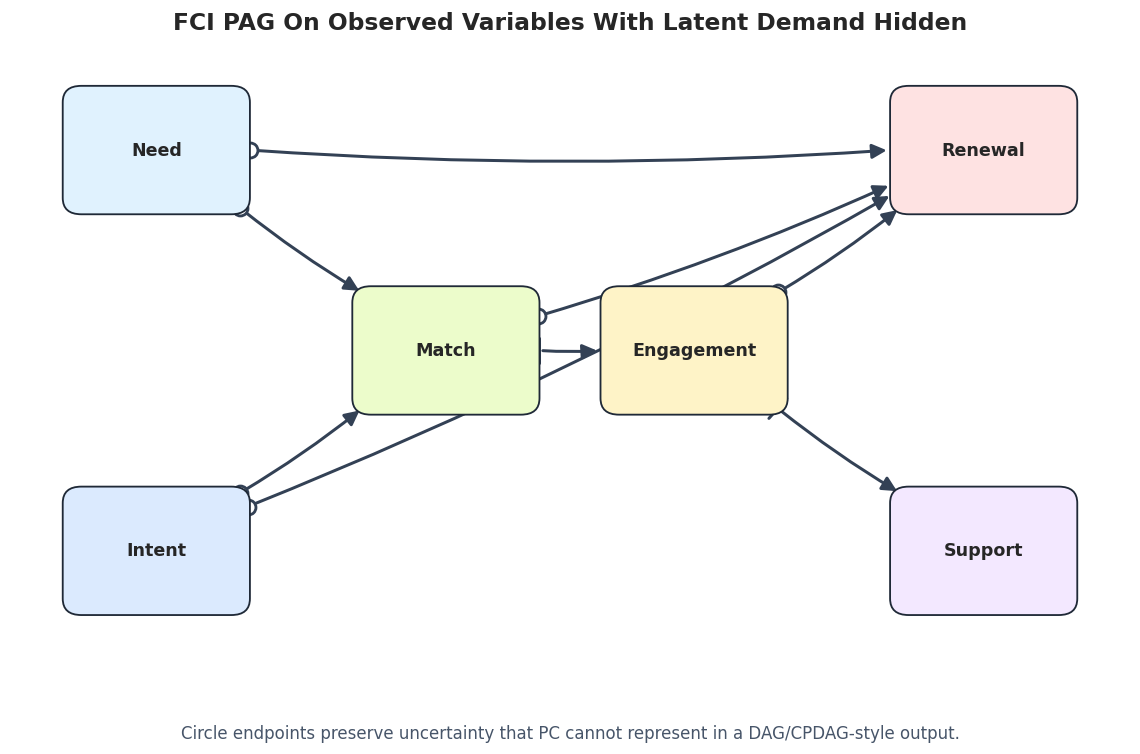

In [13]:
# Draw the FCI PAG with visible endpoint marks.
fci_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_fci_observed_pag.png"
draw_pag_or_dag(
    fci_edges,
    title="FCI PAG On Observed Variables With Latent Demand Hidden",
    path=fci_graph_path,
    positions=OBS_POS,
    note="Circle endpoints preserve uncertainty that PC cannot represent in a DAG/CPDAG-style output.",
)

The PAG is not as visually tidy as the PC graph, but that untidiness is the point. FCI is giving a more honest representation of what remains ambiguous when hidden common causes are allowed.

## PC Versus FCI: Side-By-Side Metrics

The next table compares PC and FCI using simple observed-variable metrics. These metrics are not a full PAG evaluation, but they help summarize the practical difference: PC produces more definite arrows, while FCI preserves more endpoint uncertainty.

,run,learned_edges_total,definite_directed_edges,partially_oriented_edges,bidirected_like_edges,unresolved_adjacencies,correct_definite_directed_edges,directed_precision,directed_recall,reversed_true_edges,missing_true_adjacencies,extra_adjacencies
0,pc_observed,8,8,0,0,0,6,0.75,1.000000,0,0,2
1,fci_observed,8,2,6,0,0,2,1.00,0.333333,0,0,2


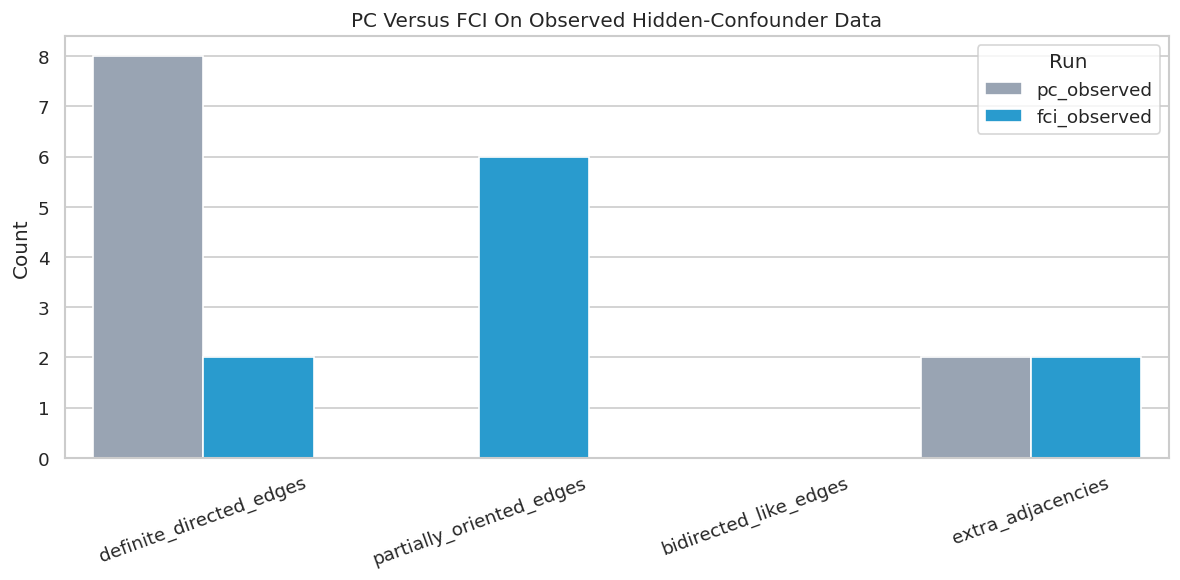

In [14]:
# Compare PC and FCI on the same observed data.
pc_fci_comparison = pd.concat([pc_metrics, fci_metrics], ignore_index=True)
pc_fci_comparison.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_pc_vs_fci_metrics.csv", index=False)

display(pc_fci_comparison)

fig, ax = plt.subplots(figsize=(10, 5))
plot_df = pc_fci_comparison.melt(
    id_vars="run",
    value_vars=["definite_directed_edges", "partially_oriented_edges", "bidirected_like_edges", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.barplot(data=plot_df, x="metric", y="count", hue="run", palette=["#94a3b8", "#0ea5e9"], ax=ax)
ax.set_title("PC Versus FCI On Observed Hidden-Confounder Data")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Run")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_pc_vs_fci_metrics.png", dpi=160, bbox_inches="tight")
plt.show()

This comparison captures the modeling tradeoff. PC is easier to read but can be too confident. FCI is harder to read but gives the analyst a language for “possible hidden structure” and “not fully resolved endpoint.”

## Focus On The Known Latent-Confounded Pair

Because this is synthetic data, we know that `match` and `renewal` share the hidden parent `latent_demand`. The next cell filters PC and FCI edge tables to the pairs directly involving `match`, `renewal`, and nearby downstream variables.

In [15]:
# Inspect edges around the known hidden-common-cause pair.
focus_nodes = {"match", "renewal", "engagement", "need", "intent"}
focused_edges = pd.concat([pc_edges, fci_edges], ignore_index=True)
focused_edges = focused_edges[
    focused_edges["source"].isin(focus_nodes) & focused_edges["target"].isin(focus_nodes)
].copy()
focused_edges["endpoint_category"] = focused_edges["edge_type"].map(endpoint_category)
focused_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_focused_match_renewal_edges.csv", index=False)

display(latent_pair_table)
display(focused_edges)

,latent_variable,observed_child_a,observed_child_b
0,latent_demand,match,renewal


,run,source,edge_type,target,edge_properties,endpoint_category
0,pc_observed,need,-->,match,not_returned,definite directed edge
1,pc_observed,need,-->,renewal,not_returned,definite directed edge
2,pc_observed,intent,-->,match,not_returned,definite directed edge
3,pc_observed,intent,-->,renewal,not_returned,definite directed edge
4,pc_observed,match,-->,engagement,not_returned,definite directed edge
5,pc_observed,match,-->,renewal,not_returned,definite directed edge
6,pc_observed,engagement,-->,renewal,not_returned,definite directed edge
8,fci_observed,need,o->,match,none,partially oriented edge
9,fci_observed,need,o->,renewal,none,partially oriented edge
10,fci_observed,intent,o->,match,none,partially oriented edge


The focused table shows how the same observed association is represented differently. PC tends to give a definite observed edge, while FCI can leave circle endpoints or weaker edge properties around the latent-risk region.

## FCI Edge Properties

causal-learn returns an edge-property list in addition to the graph. The properties are useful because they distinguish stronger statements such as “definitely direct” and “no latent” from weaker possibilities.

In [16]:
# Summarize the edge property flags returned by FCI.
property_summary = (
    fci_edges.assign(edge_properties=fci_edges["edge_properties"].fillna("none"))
    .groupby(["edge_type", "endpoint_category", "edge_properties"], dropna=False)
    .size()
    .reset_index(name="edge_count")
    .sort_values(["edge_type", "edge_properties"])
)
property_summary.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_edge_property_summary.csv", index=False)
display(property_summary)

,edge_type,endpoint_category,edge_properties,edge_count
0,-->,definite directed edge,"dd,nl",2
1,o->,partially oriented edge,none,6


The property summary reinforces the main reading habit: do not treat every PAG edge as equally strong. Some edges are marked as definitely direct with no latent signal, while others remain weaker candidate relationships.

## Oracle-Style Check: What If The Latent Variable Were Observed?

This section is a teaching check, not a real applied workflow. We run FCI on the full dataset that includes `latent_demand`. If the hidden variable is included, the algorithm has a chance to represent the latent driver as an observed node instead of expressing its influence through ambiguous observed endpoints.

In [17]:
# Run FCI on the full dataset where latent_demand is included as an observed column.
fci_full_graph, fci_full_properties, fci_full_messages = run_fci_quiet(
    full_df[FULL_VARIABLES].to_numpy(),
    label="fci_full_with_latent_observed",
    node_names=FULL_VARIABLES,
    alpha=0.05,
)

fci_full_edges = graph_to_edge_table(
    fci_full_graph,
    label="fci_full_with_latent_observed",
    edge_properties=fci_full_properties,
)
fci_full_edges["endpoint_category"] = fci_full_edges["edge_type"].map(endpoint_category)
fci_full_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_full_with_latent_edges.csv", index=False)
fci_full_messages.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_full_with_latent_messages.csv", index=False)

display(fci_full_edges)

,run,source,edge_type,target,edge_properties,endpoint_category
0,fci_full_with_latent_observed,need,o->,match,none,partially oriented edge
1,fci_full_with_latent_observed,intent,o->,match,none,partially oriented edge
2,fci_full_with_latent_observed,intent,-->,renewal,"pd,pl",definite directed edge
3,fci_full_with_latent_observed,latent_demand,o->,match,none,partially oriented edge
4,fci_full_with_latent_observed,latent_demand,-->,renewal,"pd,pl",definite directed edge
5,fci_full_with_latent_observed,match,-->,engagement,"dd,nl",definite directed edge
6,fci_full_with_latent_observed,engagement,-->,renewal,"dd,nl",definite directed edge
7,fci_full_with_latent_observed,engagement,-->,support,"dd,nl",definite directed edge


When the latent driver is available as a column, the graph can place it explicitly in the candidate structure. This is a useful reminder that “latent confounding” is partly a data-collection problem: better measurement can simplify the graph discovery task.

## Draw The Full-Data FCI Graph

The full-data FCI graph is not the main result, but it helps students see the difference between a hidden common cause and an observed common cause. Once `latent_demand` is measured, it gets its own node.

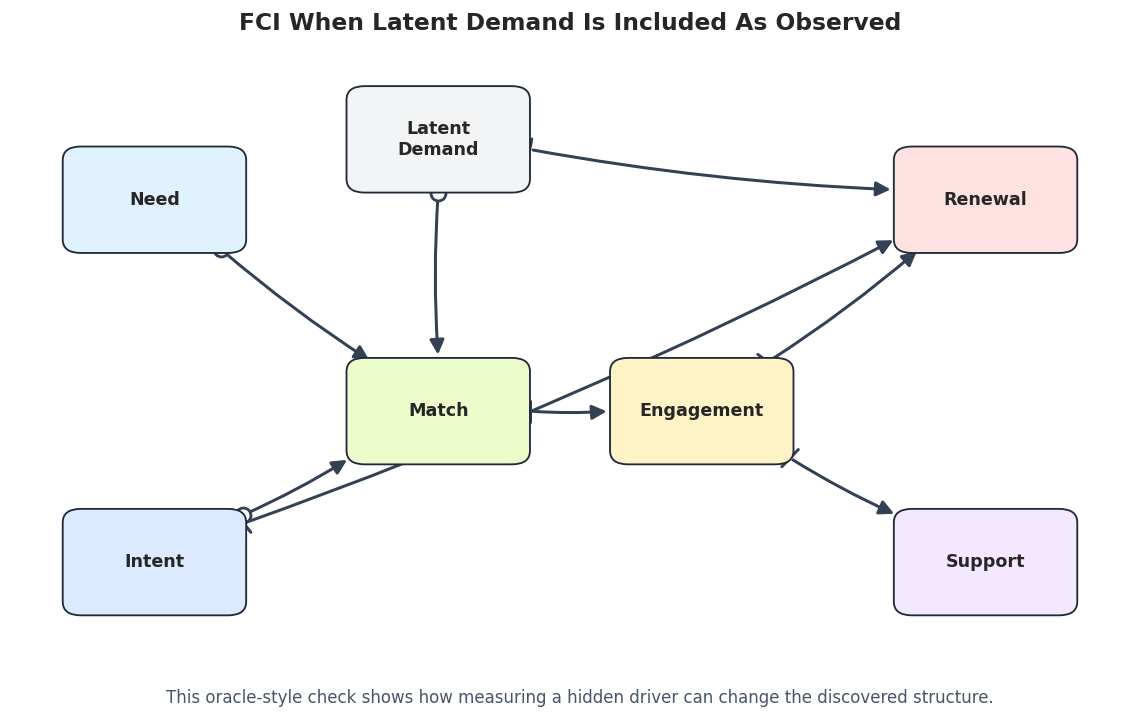

In [18]:
# Draw the FCI graph when latent_demand is included as observed.
fci_full_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_fci_full_with_latent_observed_pag.png"
draw_pag_or_dag(
    fci_full_edges,
    title="FCI When Latent Demand Is Included As Observed",
    path=fci_full_graph_path,
    positions=FULL_POS,
    note="This oracle-style check shows how measuring a hidden driver can change the discovered structure.",
)

The graph is still a PAG, not a final causal proof. But the hidden driver is now visible to the algorithm, which changes how uncertainty is distributed across the observed edges.

## Alpha Sensitivity For FCI

Like PC, FCI depends on many conditional independence tests. The `alpha` threshold controls how readily the algorithm treats a conditional independence test as evidence for removing an edge. Because endpoint marks can change with alpha, a single FCI run should not be reported without sensitivity checks.

In [19]:
# Run FCI across alpha values and summarize endpoint patterns.
alpha_values = [0.001, 0.005, 0.01, 0.05, 0.10, 0.20]
alpha_metric_rows = []
alpha_edge_tables = []
alpha_message_tables = []

for alpha in alpha_values:
    label = f"fci_alpha_{alpha:g}"
    graph, properties, messages = run_fci_quiet(
        observed_df[OBSERVED_VARIABLES].to_numpy(),
        label=label,
        node_names=OBSERVED_VARIABLES,
        alpha=alpha,
    )
    edge_table = graph_to_edge_table(graph, label=label, edge_properties=properties)
    edge_table["endpoint_category"] = edge_table["edge_type"].map(endpoint_category)
    metrics = summarize_against_observed_truth(edge_table, observed_truth, label)
    metrics.insert(1, "alpha", alpha)
    alpha_metric_rows.append(metrics)
    alpha_edge_tables.append(edge_table.assign(alpha=alpha))
    alpha_message_tables.append(messages.assign(alpha=alpha))

alpha_metrics = pd.concat(alpha_metric_rows, ignore_index=True)
alpha_edges = pd.concat(alpha_edge_tables, ignore_index=True)
alpha_messages = pd.concat(alpha_message_tables, ignore_index=True)

alpha_metrics.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_alpha_sensitivity_metrics.csv", index=False)
alpha_edges.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_alpha_sensitivity_edges.csv", index=False)
alpha_messages.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_alpha_sensitivity_messages.csv", index=False)

display(alpha_metrics)
display(alpha_edges.head(20))

,run,alpha,learned_edges_total,definite_directed_edges,partially_oriented_edges,bidirected_like_edges,unresolved_adjacencies,correct_definite_directed_edges,directed_precision,directed_recall,reversed_true_edges,missing_true_adjacencies,extra_adjacencies
0,fci_alpha_0.001,0.001,7,3,1,3,0,2,0.666667,0.333333,1,0,1
1,fci_alpha_0.005,0.005,7,2,3,2,0,2,1.000000,0.333333,0,0,1
2,fci_alpha_0.01,0.010,7,2,3,2,0,2,1.000000,0.333333,0,0,1
3,fci_alpha_0.05,0.050,8,2,6,0,0,2,1.000000,0.333333,0,0,2
4,fci_alpha_0.1,0.100,8,2,6,0,0,2,1.000000,0.333333,0,0,2
5,fci_alpha_0.2,0.200,9,2,7,0,0,2,1.000000,0.333333,0,0,3


,run,source,edge_type,target,edge_properties,endpoint_category,alpha
0,fci_alpha_0.001,need,o->,match,none,partially oriented edge,0.001
1,fci_alpha_0.001,intent,<->,match,none,possible latent-confounding edge,0.001
2,fci_alpha_0.001,renewal,-->,intent,"dd,nl",definite directed edge,0.001
3,fci_alpha_0.001,match,-->,engagement,"dd,nl",definite directed edge,0.001
4,fci_alpha_0.001,match,<->,renewal,none,possible latent-confounding edge,0.001
5,fci_alpha_0.001,engagement,<->,renewal,none,possible latent-confounding edge,0.001
6,fci_alpha_0.001,engagement,-->,support,"dd,nl",definite directed edge,0.001
7,fci_alpha_0.005,need,o->,match,none,partially oriented edge,0.005
8,fci_alpha_0.005,intent,o->,match,none,partially oriented edge,0.005
9,fci_alpha_0.005,intent,o->,renewal,none,partially oriented edge,0.005


The alpha table shows that both adjacencies and endpoint marks can move as the test threshold changes. This is why FCI should be reported as a stability-sensitive candidate graph, not as a single immutable answer.

## Plot FCI Alpha Sensitivity

The plot tracks the counts of total edges, definite directed edges, partially oriented edges, and bidirected-like edges across alpha values. It is easier to spot tuning sensitivity here than in a long edge table.

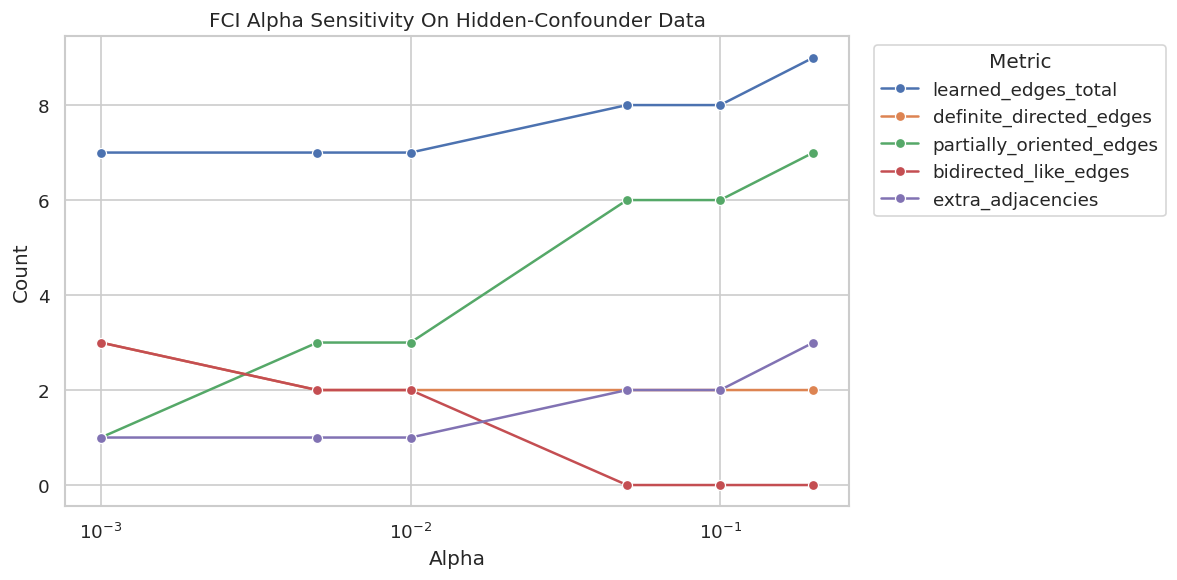

In [20]:
# Plot endpoint-pattern sensitivity across alpha values.
fig, ax = plt.subplots(figsize=(10, 5))
plot_df = alpha_metrics.melt(
    id_vars=["run", "alpha"],
    value_vars=["learned_edges_total", "definite_directed_edges", "partially_oriented_edges", "bidirected_like_edges", "extra_adjacencies"],
    var_name="metric",
    value_name="count",
)
sns.lineplot(data=plot_df, x="alpha", y="count", hue="metric", marker="o", ax=ax)
ax.set_xscale("log")
ax.set_title("FCI Alpha Sensitivity On Hidden-Confounder Data")
ax.set_xlabel("Alpha")
ax.set_ylabel("Count")
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(FIGURE_DIR / f"{NOTEBOOK_PREFIX}_fci_alpha_sensitivity.png", dpi=160, bbox_inches="tight")
plt.show()

The plot turns endpoint instability into something visible. If a result changes sharply across reasonable alpha values, the report should emphasize uncertainty and avoid strong edge-level claims.

## Draw A Low-Alpha FCI PAG

At stricter alpha values, FCI can remove or alter some edges and endpoint marks. Drawing one alternative PAG makes the sensitivity analysis more concrete.

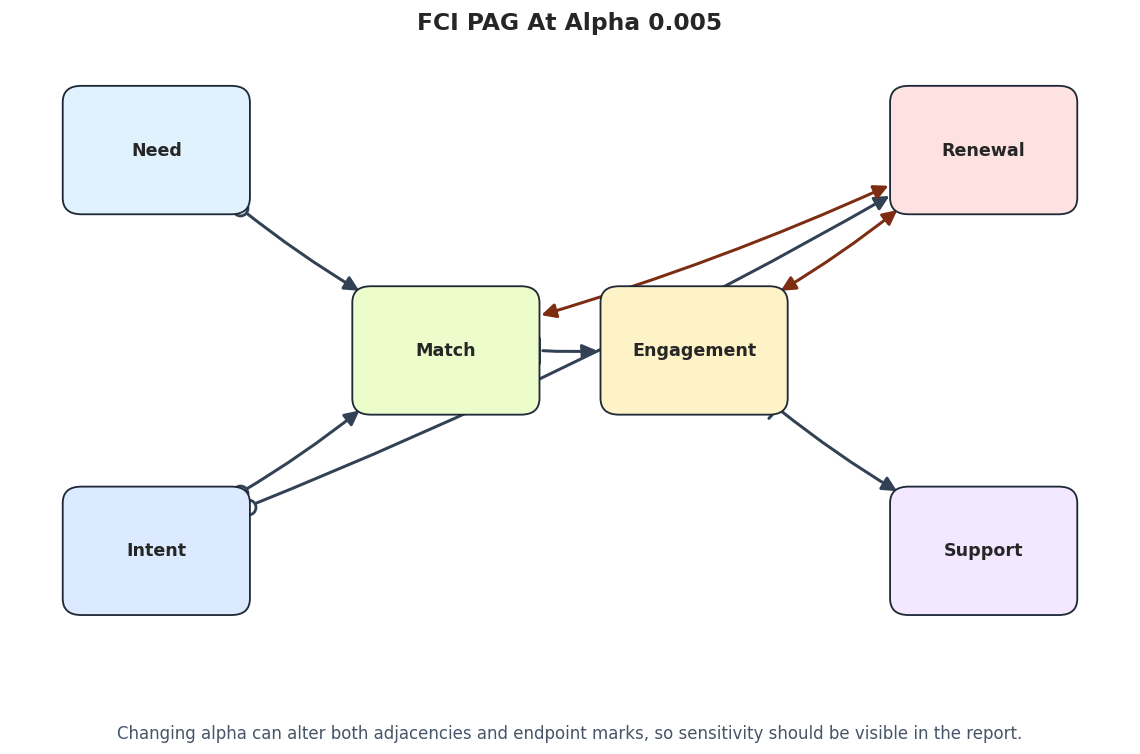

In [21]:
# Draw one stricter-alpha FCI graph for visual comparison.
low_alpha_edges = alpha_edges[alpha_edges["alpha"] == 0.005].drop(columns=["alpha"])
low_alpha_graph_path = FIGURE_DIR / f"{NOTEBOOK_PREFIX}_fci_low_alpha_pag.png"
draw_pag_or_dag(
    low_alpha_edges,
    title="FCI PAG At Alpha 0.005",
    path=low_alpha_graph_path,
    positions=OBS_POS,
    note="Changing alpha can alter both adjacencies and endpoint marks, so sensitivity should be visible in the report.",
)

The stricter-alpha graph gives a visual example of why one PAG should not be over-read. The stable parts are more credible than edges or endpoint marks that move when tuning changes.

## Practical Reading Guide For The Main FCI PAG

This cell converts the main FCI edge table into plain-language statements. It is not a substitute for graph theory, but it helps students practice careful wording.

In [22]:
# Translate FCI edges into cautious report language.
reading_rows = []
for row in fci_edges.itertuples(index=False):
    if row.edge_type == "-->":
        statement = f"{row.source} has a definite directed endpoint toward {row.target} in this PAG."
    elif row.edge_type == "o->":
        statement = f"{row.target} has an arrowhead, but the endpoint at {row.source} remains unresolved."
    elif row.edge_type == "<->":
        statement = f"{row.source} and {row.target} have arrowheads at both ends, consistent with latent or ancestral uncertainty."
    elif row.edge_type == "o-o":
        statement = f"{row.source} and {row.target} are adjacent, but both endpoints remain unresolved."
    else:
        statement = f"{row.source} {row.edge_type} {row.target} requires careful PAG-specific reading."
    reading_rows.append(
        {
            "edge": f"{row.source} {row.edge_type} {row.target}",
            "edge_properties": row.edge_properties,
            "careful_report_language": statement,
        }
    )

fci_reading_guide = pd.DataFrame(reading_rows)
fci_reading_guide.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_fci_reading_guide.csv", index=False)
display(fci_reading_guide)

,edge,edge_properties,careful_report_language
0,need o-> match,none,"match has an arrowhead, but the endpoint at ne..."
1,need o-> renewal,none,"renewal has an arrowhead, but the endpoint at ..."
2,intent o-> match,none,"match has an arrowhead, but the endpoint at in..."
3,intent o-> renewal,none,"renewal has an arrowhead, but the endpoint at ..."
4,match --> engagement,"dd,nl",match has a definite directed endpoint toward ...
5,match o-> renewal,none,"renewal has an arrowhead, but the endpoint at ..."
6,engagement o-> renewal,none,"renewal has an arrowhead, but the endpoint at ..."
7,engagement --> support,"dd,nl",engagement has a definite directed endpoint to...


This kind of wording keeps the analysis honest. The safest FCI reports avoid translating every PAG edge into a direct causal sentence and instead preserve the uncertainty encoded by the endpoints.

## Latent-Confounder Reporting Checklist

The final checklist is the reusable takeaway. It is written for a real analysis where the full synthetic truth is unavailable and the analyst must report assumptions, diagnostics, and limitations clearly.

In [23]:
# Save a checklist for reporting FCI results in applied causal discovery work.
reporting_checklist = pd.DataFrame(
    [
        {
            "topic": "why FCI",
            "question_to_answer": "Why is hidden confounding plausible enough that PC alone is too optimistic?",
            "reporting_note": "Explain the measurement gap or omitted common-cause risk.",
        },
        {
            "topic": "PAG endpoint marks",
            "question_to_answer": "Which edges are definite, partially oriented, bidirected-like, or unresolved?",
            "reporting_note": "Do not rewrite circle endpoints as fully directed causal claims.",
        },
        {
            "topic": "edge properties",
            "question_to_answer": "Which returned edges are marked definitely direct or no-latent versus weaker possibilities?",
            "reporting_note": "Use edge properties to separate stronger and weaker statements.",
        },
        {
            "topic": "sensitivity",
            "question_to_answer": "How do adjacencies and endpoints change across alpha values or test choices?",
            "reporting_note": "Stable patterns deserve more attention than tuning-specific marks.",
        },
        {
            "topic": "measurement improvements",
            "question_to_answer": "Which omitted variables would make the discovery problem less ambiguous if measured?",
            "reporting_note": "FCI can point to ambiguity, but better data often resolves more than another algorithm run.",
        },
    ]
)
reporting_checklist.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_latent_confounder_reporting_checklist.csv", index=False)
display(reporting_checklist)

,topic,question_to_answer,reporting_note
0,why FCI,Why is hidden confounding plausible enough tha...,Explain the measurement gap or omitted common-...
1,PAG endpoint marks,"Which edges are definite, partially oriented, ...",Do not rewrite circle endpoints as fully direc...
2,edge properties,Which returned edges are marked definitely dir...,Use edge properties to separate stronger and w...
3,sensitivity,How do adjacencies and endpoints change across...,Stable patterns deserve more attention than tu...
4,measurement improvements,Which omitted variables would make the discove...,"FCI can point to ambiguity, but better data of..."


The checklist is the bridge from tutorial to practice. FCI is useful because it makes hidden-confounder uncertainty visible, but the analyst still has to document why hidden confounding is plausible and which graph claims are stable.

## Artifact Manifest

The final code cell lists the files generated by this notebook. Keeping an artifact manifest makes it easier to find the saved edge tables, sensitivity results, and figures later.

In [24]:
# Inventory the artifacts generated by this notebook.
artifact_rows = []
for folder, artifact_type in [(TABLE_DIR, "table"), (FIGURE_DIR, "figure")]:
    for artifact_path in sorted(folder.glob(f"{NOTEBOOK_PREFIX}_*")):
        artifact_rows.append(
            {
                "artifact_type": artifact_type,
                "file_name": artifact_path.name,
                "relative_path": str(artifact_path.relative_to(NOTEBOOK_DIR)),
                "size_kb": round(artifact_path.stat().st_size / 1024, 1),
            }
        )

artifact_manifest = pd.DataFrame(artifact_rows)
artifact_manifest.to_csv(TABLE_DIR / f"{NOTEBOOK_PREFIX}_artifact_manifest.csv", index=False)
display(artifact_manifest)

,artifact_type,file_name,relative_path,size_kb
0,table,06_artifact_manifest.csv,outputs/tables/06_artifact_manifest.csv,2.8
1,table,06_fci_alpha_sensitivity_edges.csv,outputs/tables/06_fci_alpha_sensitivity_edges.csv,3.2
2,table,06_fci_alpha_sensitivity_messages.csv,outputs/tables/06_fci_alpha_sensitivity_messag...,0.5
3,table,06_fci_alpha_sensitivity_metrics.csv,outputs/tables/06_fci_alpha_sensitivity_metric...,0.6
4,table,06_fci_edge_property_summary.csv,outputs/tables/06_fci_edge_property_summary.csv,0.1
5,table,06_fci_full_with_latent_edges.csv,outputs/tables/06_fci_full_with_latent_edges.csv,0.7
6,table,06_fci_full_with_latent_messages.csv,outputs/tables/06_fci_full_with_latent_message...,0.2
7,table,06_fci_observed_edge_classification.csv,outputs/tables/06_fci_observed_edge_classifica...,0.7
8,table,06_fci_observed_edges.csv,outputs/tables/06_fci_observed_edges.csv,0.5
9,table,06_fci_observed_messages.csv,outputs/tables/06_fci_observed_messages.csv,0.1


The notebook now has a full FCI workflow: latent-variable setup, PC baseline, FCI PAG, endpoint reading guide, oracle-style full-data check, alpha sensitivity, and reporting artifacts. The next tutorial notebook can move to CD-NOD, where the discovery problem changes from hidden confounding to nonstationary or changing environments.